# ICP Problem formulation 

<img src="i/ab.png" width=600>


$$\text{Given 2 point clouds} \quad $$

$$
A = 
\begin{bmatrix} 
    x_1 & x_2 & \cdot\cdot\cdot & x_N \\ 
    y_1 & y_2 & \cdot\cdot\cdot & y_N \\ 
\end{bmatrix}, \quad 
B = 
\begin{bmatrix} 
    u_1 & u_2 & \cdot\cdot\cdot & u_M \\ 
    v_1 & v_2 & \cdot\cdot\cdot & v_M \\ 
\end{bmatrix}
\\ 
$$

$$\text{Find motion } \space (R, t) \space \text{s.t.} \quad 

\begin{bmatrix} 
    u_j \\ 
    v_j \\
\end{bmatrix} 
= 
R 
\begin{bmatrix} 
    x_i \\ 
    y_i  \\ 
\end{bmatrix} + t

\text{ is most consistent for all } i = 1, 2,..., N
$$

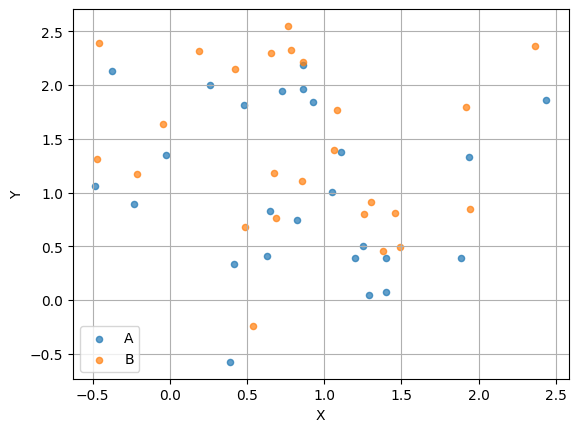

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
A = np.loadtxt('data/A.txt') 
B = np.loadtxt('data/B.txt')

def plot_points(A, B):
    x, y = A 
    plt.scatter(x, y, s=20, alpha=0.7, label="A")

    x, y = B 
    plt.scatter(x, y, s=20, alpha=0.7, label="B")

    plt.grid(True)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

plot_points(A, B) 

## 2D rigid alignment problem

Given two corresponding point sets, find the rotation $𝑅 ∈ 𝑆𝑂(2)$,  and translation $ 𝑡 \in 𝑅^2$ that best aligns them in the least-squares sense.

$$
\text { Mathematically Given } \\
A =
\begin{bmatrix} 
    a_1, \cdot\cdot\cdot, a_N 
\end{bmatrix}, 
B = 
\begin{bmatrix} 
    b_1, \cdot\cdot\cdot, b_N 
\end{bmatrix}, a_i, b_i \in R^2 \\ 
$$

$$
\text{Find} \quad \hat{R}, \hat{t} = \argmin_{R, t} \sum_{i=1}^{N} {||b_i - (R a_i + t)||^2} \\
            \text {s.t.} \quad R^T R = 
                                        \begin{bmatrix} 
                                                1 & 0 \\
                                                0 & 1
                                            \end{bmatrix} \\ 
             \det(R) = 1
$$

## Equivalent problem

$$
\text { Given } \\
A =
\begin{bmatrix} 
    a_1, \cdot\cdot\cdot, a_N 
\end{bmatrix}, 
B = 
\begin{bmatrix} 
    b_1, \cdot\cdot\cdot, b_N 
\end{bmatrix}, a_i, b_i \in R^2 \\ 
$$

$$
\text{Find} \quad R^{\\*}, t^{\\*} = \argmin_{R, t} ||B - (R A + t)||^2_{F} \\
            \text {s.t.} \quad R^T R = 
                                        \begin{bmatrix} 
                                                1 & 0 \\
                                                0 & 1
                                            \end{bmatrix} \\ 
             \det(R) = 1
$$


## Globally optimal rigid motion

Assummtion: 
- Points are in correct correspondence: A[:, i] matches B[:, i]
- No strong outliers. One bad point can skew SVD 

In [23]:
def estimate_motion(A:np.ndarray , B:np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Compute centroids
    Ac = A.mean(axis=1)
    Bc = B.mean(axis=1)
    
    # Center the points 
    AA = A-Ac.reshape(2, -1) 
    BB = B-Bc.reshape(2, -1)

    # Cross-covariance
    H = AA @ BB.T 

    # SVD
    U, S, Vt = np.linalg.svd(H)

    # Rotation
    R = Vt.T @ U.T 

    if np.linalg.det(R) < 0:
        Vt[-1] = -Vt[-1]
        R = Vt.T @ U.T 

    t = Bc - R @ Ac 
    return (R, t)

R, t = estimate_motion(A, B)
Rsol = np.loadtxt("data/R.txt")
tsol = np.loadtxt("data/t.txt")

